# Phase 13 — Monitoring

## Contexte — Pourquoi le monitoring est critique ici

La Phase 11 a révélé un **drift AUPRC de −0.106 en seulement 5 heures** (0.803 → 0.698).  
En production sur des semaines/mois, ce drift serait bien plus sévère.

**Raison fondamentale** : les fraudeurs s'adaptent en continu aux systèmes de détection.  
Un modèle figé se dégrade inévitablement — c'est documenté dans les papiers ULB.

## Ce qu'on implémente
| # | Composant | Outil |
|---|---|---|
| 1 | Drift des features (V*, Amount, hour) | Test de Kolmogorov-Smirnov |
| 2 | Drift des prédictions (scores) | PSI + KS |
| 3 | Drift de performance (AUPRC) | Fenêtre glissante |
| 4 | Seuils de déclenchement retraining | Règles documentées |
| 5 | Discussion feedback loop | Biais de sélection |

> **Note** : on utilise `train` comme référence et `test` comme snapshot  
> pour simuler le flux de nouvelles données en production.

## Plan
1. Chargement
2. Drift des features (KS test)
3. PSI — Population Stability Index
4. Drift des scores de prédiction
5. AUPRC en fenêtre glissante
6. Dashboard de monitoring
7. Seuils & triggers de retraining
8. Discussion feedback loop
9. Conclusions

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json, warnings
from pathlib import Path
from scipy import stats
from sklearn.metrics import average_precision_score

from src.config import RANDOM_SEED

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement

In [2]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
model        = joblib.load(MODELS_PATH / 'pipeline_final.joblib')

with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
with open(MODELS_PATH / 'final_model_config.json') as f:
    final_cfg = json.load(f)

FEAT_COLS = feat_cfg['all_feat_cols']
THRESHOLD = final_cfg['threshold']
V_COLS    = [f'V{i}' for i in range(1, 29)]

# Scores
X_train = preprocessor.transform(train[FEAT_COLS])
X_test  = preprocessor.transform(test[FEAT_COLS])
scores_train = model.predict_proba(X_train)[:, 1]
scores_test  = model.predict_proba(X_test)[:, 1]

print(f'Référence (train) : {len(train):,} lignes | {train["Class"].sum()} fraudes')
print(f'Snapshot  (test)  : {len(test):,}  lignes | {test["Class"].sum()} fraudes')

Référence (train) : 210,292 lignes | 376 fraudes
Snapshot  (test)  : 73,434  lignes | 97 fraudes


## 2. Drift des features — Test de Kolmogorov-Smirnov

Le **test KS** compare les distributions train vs test pour chaque feature.  
Un p-value < 0.05 indique un drift statistiquement significatif.

In [3]:
# Features à surveiller : V* + Amount + hour
monitor_cols = V_COLS + ['Amount']
if 'hour' in train.columns:
    monitor_cols += ['hour']

ks_results = []
for col in monitor_cols:
    if col not in train.columns or col not in test.columns:
        continue
    stat, pval = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    ks_results.append({
        'Feature'  : col,
        'KS stat'  : round(stat, 4),
        'p-value'  : round(pval, 6),
        'Drift ?'  : 'OUI 🔴' if pval < 0.05 else 'NON ✅',
        'Sévérité' : 'HAUTE' if stat > 0.1 else 'FAIBLE',
    })

df_ks = pd.DataFrame(ks_results).sort_values('KS stat', ascending=False)
n_drift = (df_ks['p-value'] < 0.05).sum()
print(f'Features en drift (p < 0.05) : {n_drift} / {len(df_ks)}')
print()
print('Top 10 features les plus driftées :')
print(df_ks.head(10).to_string(index=False))

Features en drift (p < 0.05) : 30 / 30

Top 10 features les plus driftées :
Feature  KS stat  p-value Drift ? Sévérité
   hour   0.5953      0.0   OUI 🔴    HAUTE
     V3   0.3769      0.0   OUI 🔴    HAUTE
     V1   0.2854      0.0   OUI 🔴    HAUTE
    V28   0.2420      0.0   OUI 🔴    HAUTE
    V25   0.2253      0.0   OUI 🔴    HAUTE
    V15   0.1815      0.0   OUI 🔴    HAUTE
     V5   0.1692      0.0   OUI 🔴    HAUTE
    V11   0.1551      0.0   OUI 🔴    HAUTE
    V23   0.1422      0.0   OUI 🔴    HAUTE
     V4   0.1402      0.0   OUI 🔴    HAUTE


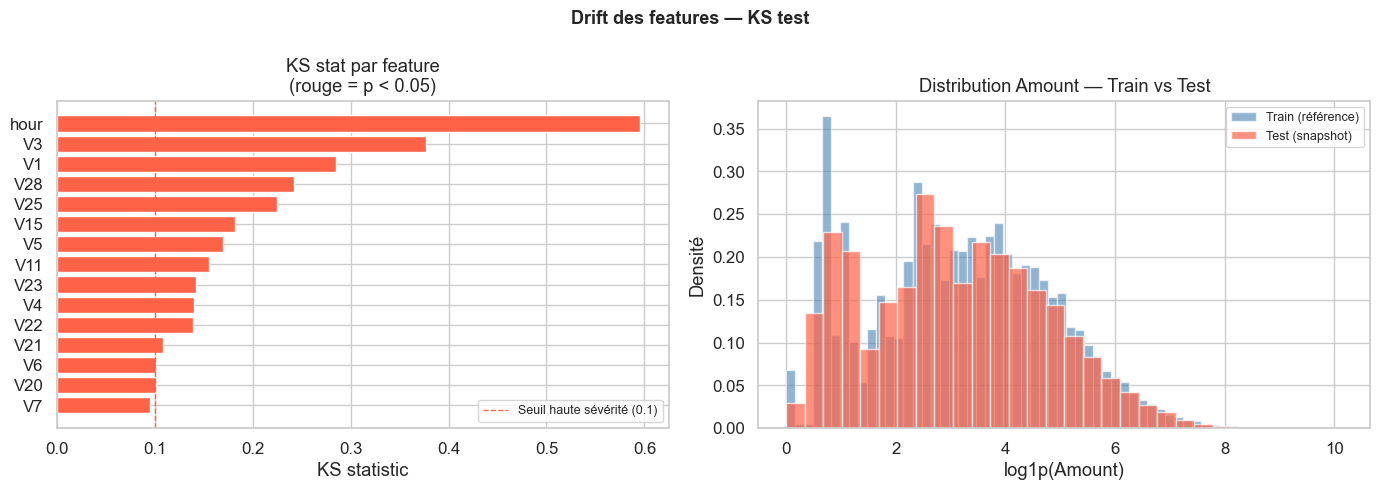

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KS stat par feature
top_ks = df_ks.head(15)
colors_ks = ['tomato' if p < 0.05 else 'steelblue'
             for p in top_ks['p-value']]
axes[0].barh(top_ks['Feature'][::-1], top_ks['KS stat'][::-1],
             color=colors_ks[::-1], edgecolor='white')
axes[0].axvline(0.1, color='tomato', linestyle='--', linewidth=1,
                label='Seuil haute sévérité (0.1)')
axes[0].set_title('KS stat par feature\n(rouge = p < 0.05)')
axes[0].set_xlabel('KS statistic')
axes[0].legend(fontsize=9)

# Distribution Amount train vs test
axes[1].hist(np.log1p(train['Amount']), bins=60, alpha=0.6,
             color='steelblue', label='Train (référence)', density=True)
axes[1].hist(np.log1p(test['Amount']),  bins=30, alpha=0.7,
             color='tomato',    label='Test (snapshot)',  density=True)
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution Amount — Train vs Test')
axes[1].legend(fontsize=9)

plt.suptitle('Drift des features — KS test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig29_feature_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PSI — Population Stability Index

Le **PSI** mesure le drift global d'une distribution en comparant  
les fréquences par bucket entre référence et snapshot.

| PSI | Interprétation |
|---|---|
| < 0.10 | Pas de changement significatif |
| 0.10 – 0.25 | Changement modéré — surveiller |
| > 0.25 | Changement majeur — **retraining** |

In [5]:
def compute_psi(ref, cur, n_bins=10):
    """Population Stability Index entre deux distributions."""
    breakpoints = np.percentile(ref, np.linspace(0, 100, n_bins + 1))
    breakpoints  = np.unique(breakpoints)
    if len(breakpoints) < 2:
        return 0.0
    ref_counts = np.histogram(ref, bins=breakpoints)[0]
    cur_counts = np.histogram(cur, bins=breakpoints)[0]
    ref_pct = ref_counts / ref_counts.sum() + 1e-6
    cur_pct = cur_counts / cur_counts.sum() + 1e-6
    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return round(float(psi), 4)

psi_results = []
for col in V_COLS + ['Amount']:
    if col in train.columns and col in test.columns:
        psi = compute_psi(train[col].values, test[col].values)
        psi_results.append({
            'Feature'  : col,
            'PSI'      : psi,
            'Statut'   : ('🔴 MAJEUR' if psi > 0.25
                          else '⚠️ MODÉRÉ' if psi > 0.10
                          else '✅ STABLE'),
        })

df_psi = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)
print('=== PSI par feature ===')
print(df_psi.to_string(index=False))
print(f'\nFeatures PSI > 0.25 (retraining) : {(df_psi["PSI"] > 0.25).sum()}')
print(f'Features PSI > 0.10 (surveiller) : {(df_psi["PSI"] > 0.10).sum()}')

=== PSI par feature ===
Feature    PSI    Statut
     V1 0.8800  🔴 MAJEUR
     V3 0.6798  🔴 MAJEUR
    V28 0.4687  🔴 MAJEUR
    V11 0.3092  🔴 MAJEUR
    V25 0.2332 ⚠️ MODÉRÉ
    V15 0.1928 ⚠️ MODÉRÉ
    V12 0.1768 ⚠️ MODÉRÉ
    V22 0.1414 ⚠️ MODÉRÉ
     V5 0.1384 ⚠️ MODÉRÉ
     V4 0.1194 ⚠️ MODÉRÉ
    V23 0.1173 ⚠️ MODÉRÉ
    V24 0.1155 ⚠️ MODÉRÉ
    V26 0.1122 ⚠️ MODÉRÉ
    V21 0.0888  ✅ STABLE
    V14 0.0656  ✅ STABLE
     V7 0.0654  ✅ STABLE
     V6 0.0562  ✅ STABLE
     V9 0.0520  ✅ STABLE
    V20 0.0472  ✅ STABLE
     V8 0.0417  ✅ STABLE
    V27 0.0384  ✅ STABLE
    V13 0.0361  ✅ STABLE
    V17 0.0339  ✅ STABLE
    V10 0.0290  ✅ STABLE
    V19 0.0238  ✅ STABLE
    V18 0.0208  ✅ STABLE
     V2 0.0156  ✅ STABLE
    V16 0.0062  ✅ STABLE
 Amount 0.0058  ✅ STABLE

Features PSI > 0.25 (retraining) : 4
Features PSI > 0.10 (surveiller) : 13


## 4. Drift des scores de prédiction

On compare la distribution des scores du modèle entre le train et le test.  
Un drift des scores est le signal le plus direct de dégradation.

Drift des scores — KS stat : 0.1369  p-value : 0.000000
Drift des scores — PSI     : 0.0915

Taux de fraude prédit train : 0.257 %
Taux de fraude prédit test  : 0.267 %


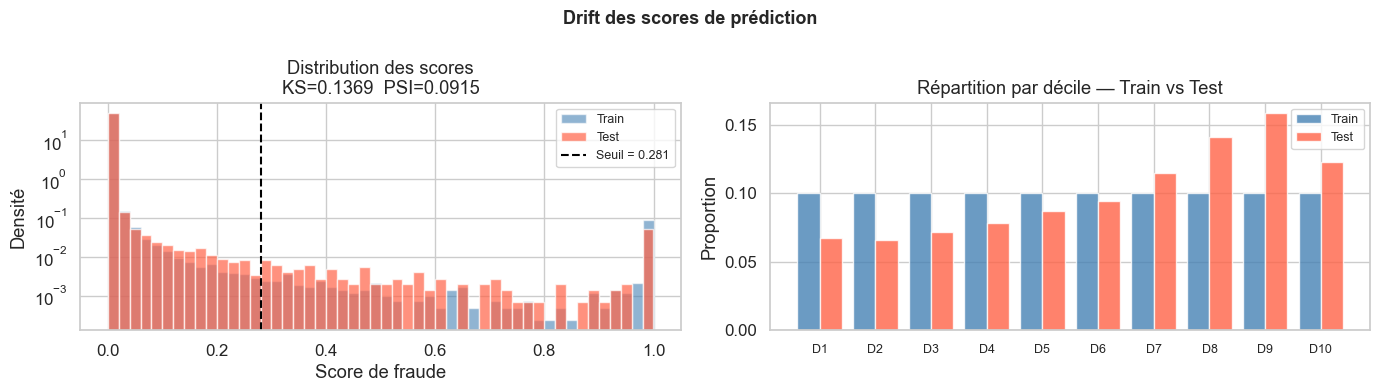

In [6]:
# KS sur les scores
ks_score, pv_score = stats.ks_2samp(scores_train, scores_test)
psi_score = compute_psi(scores_train, scores_test)

print(f'Drift des scores — KS stat : {ks_score:.4f}  p-value : {pv_score:.6f}')
print(f'Drift des scores — PSI     : {psi_score:.4f}')
print()
print(f'Taux de fraude prédit train : {(scores_train >= THRESHOLD).mean()*100:.3f} %')
print(f'Taux de fraude prédit test  : {(scores_test  >= THRESHOLD).mean()*100:.3f} %')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution des scores
axes[0].hist(scores_train, bins=50, alpha=0.6,
             color='steelblue', label='Train', density=True)
axes[0].hist(scores_test,  bins=50, alpha=0.7,
             color='tomato',    label='Test',  density=True)
axes[0].axvline(THRESHOLD, color='black', linestyle='--',
                linewidth=1.5, label=f'Seuil = {THRESHOLD}')
axes[0].set_xlabel('Score de fraude')
axes[0].set_ylabel('Densité')
axes[0].set_title(f'Distribution des scores\nKS={ks_score:.4f}  PSI={psi_score:.4f}')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')

# Taux alertes par décile de score
deciles = np.percentile(scores_train, np.arange(0, 110, 10))
tr_rate = [((scores_train >= d) & (scores_train < deciles[i+1])).mean()
           for i, d in enumerate(deciles[:-1])]
te_rate = [((scores_test  >= d) & (scores_test  < deciles[i+1])).mean()
           for i, d in enumerate(deciles[:-1])]
x = np.arange(10)
axes[1].bar(x - 0.2, tr_rate, 0.4, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, te_rate, 0.4, label='Test',  color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'D{i+1}' for i in range(10)], fontsize=9)
axes[1].set_ylabel('Proportion')
axes[1].set_title('Répartition par décile — Train vs Test')
axes[1].legend(fontsize=9)

plt.suptitle('Drift des scores de prédiction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig30_score_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. AUPRC en fenêtre glissante

On calcule l'AUPRC sur des fenêtres temporelles glissantes du test  
pour visualiser la dégradation progressive du modèle dans le temps.

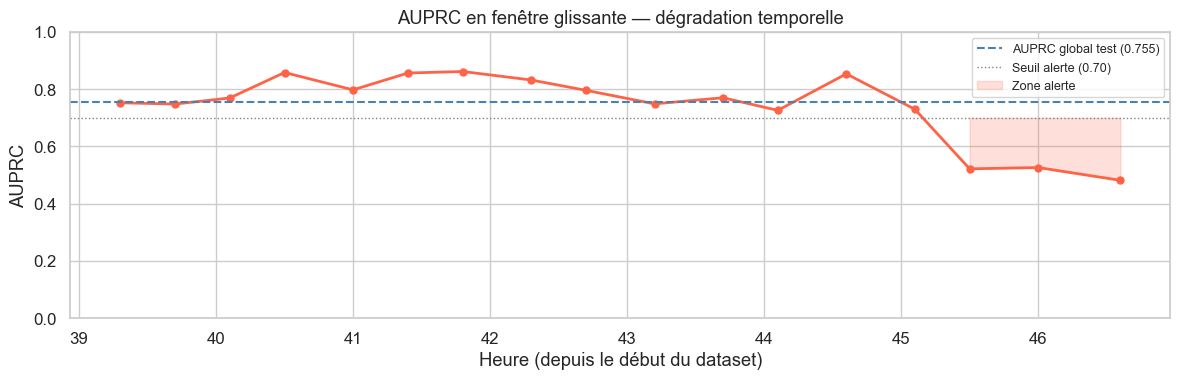

 time_h  auprc  n_fraud
   39.3 0.7526       21
   39.7 0.7481       18
   40.1 0.7693       19
   40.5 0.8583       20
   41.0 0.7977       22
   41.4 0.8565       28
   41.8 0.8618       27
   42.3 0.8321       30
   42.7 0.7960       30
   43.2 0.7488       25
   43.7 0.7701       25
   44.1 0.7261       20
   44.6 0.8536       13
   45.1 0.7299       11
   45.5 0.5218       12
   46.0 0.5264       10
   46.6 0.4817       11


In [7]:
# Trier le test par Time
test_sorted = test.sort_values('Time').reset_index(drop=True)
X_sorted    = preprocessor.transform(test_sorted[FEAT_COLS])
sc_sorted   = model.predict_proba(X_sorted)[:, 1]
y_sorted    = test_sorted['Class'].values

# Fenêtre glissante : 20% du test (environ 14 686 transactions)
window_size = max(len(test_sorted) // 5, 1000)
step        = window_size // 4

windows = []
for start in range(0, len(test_sorted) - window_size, step):
    end  = start + window_size
    y_w  = y_sorted[start:end]
    sc_w = sc_sorted[start:end]
    if y_w.sum() < 3:  # pas assez de fraudes
        continue
    t_mid = test_sorted.iloc[start + window_size // 2]['Time'] / 3600
    auprc = average_precision_score(y_w, sc_w)
    windows.append({'time_h': round(t_mid, 1), 'auprc': round(auprc, 4),
                    'n_fraud': int(y_w.sum())})

df_win = pd.DataFrame(windows)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_win['time_h'], df_win['auprc'],
        color='tomato', linewidth=2, marker='o', markersize=5)
ax.axhline(0.755, color='steelblue', linestyle='--', linewidth=1.5,
           label='AUPRC global test (0.755)')
ax.axhline(0.70, color='gray', linestyle=':', linewidth=1,
           label='Seuil alerte (0.70)')
ax.fill_between(df_win['time_h'], df_win['auprc'], 0.70,
                where=[v < 0.70 for v in df_win['auprc']],
                alpha=0.2, color='tomato', label='Zone alerte')
ax.set_xlabel('Heure (depuis le début du dataset)')
ax.set_ylabel('AUPRC')
ax.set_title('AUPRC en fenêtre glissante — dégradation temporelle')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig31_auprc_sliding.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_win.to_string(index=False))

## 6. Dashboard de monitoring synthétique

Résumé de l'état de santé du modèle en un coup d'œil.

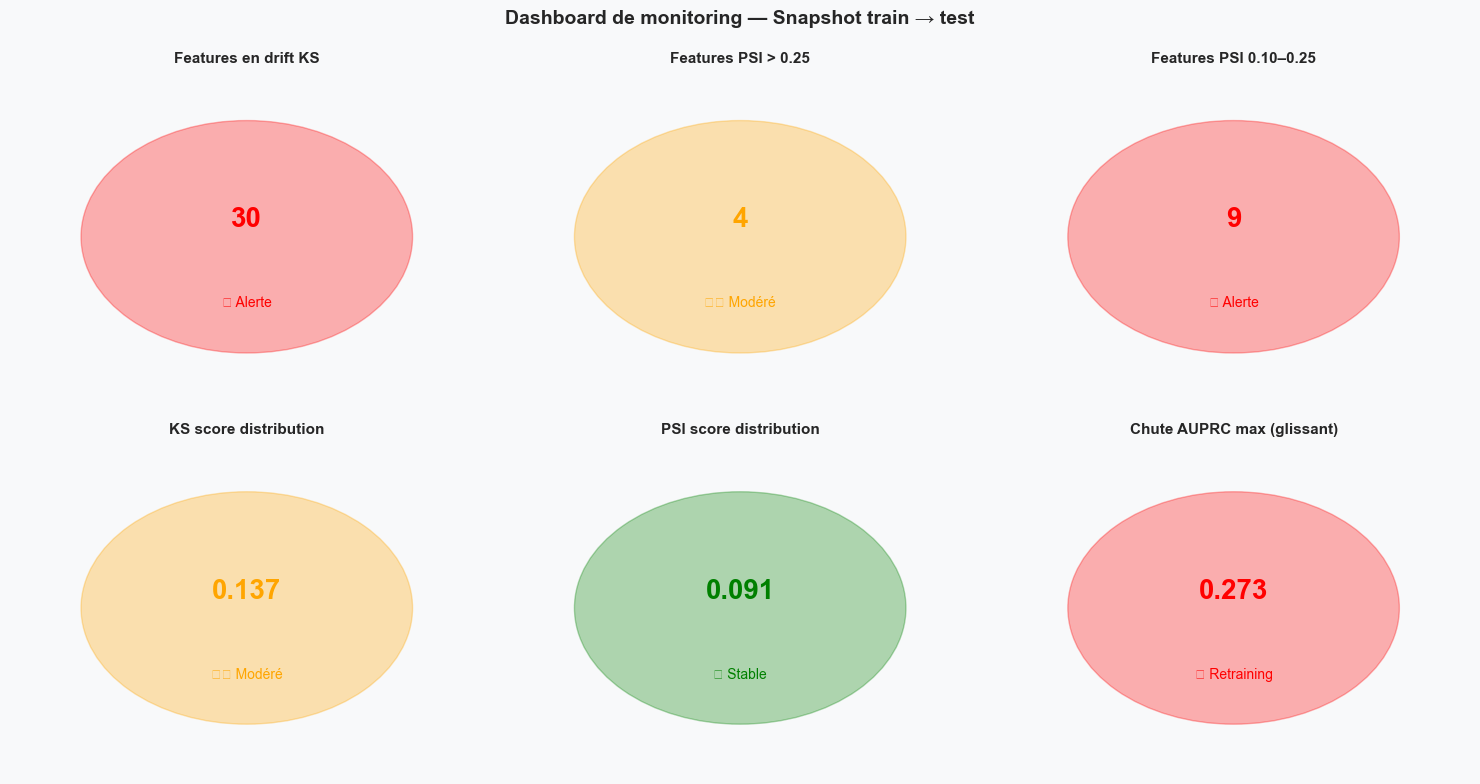

In [8]:
# Récapitulatif des indicateurs
n_ks_drift = (df_ks['p-value'] < 0.05).sum()
n_psi_maj  = (df_psi['PSI'] > 0.25).sum()
n_psi_mod  = ((df_psi['PSI'] > 0.10) & (df_psi['PSI'] <= 0.25)).sum()
auprc_drop = 0.755 - df_win['auprc'].min() if len(df_win) else 0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.patch.set_facecolor('#f8f9fa')

def gauge(ax, value, title, thresholds, labels, colors):
    """Affiche un indicateur simple."""
    ax.axis('off')
    for i, (lo, hi) in enumerate(zip([0]+thresholds, thresholds+[999])):
        if lo <= value < hi:
            color = colors[i]
            label = labels[i]
            break
    else:
        color, label = colors[-1], labels[-1]
    ax.add_patch(plt.Circle((0.5, 0.5), 0.35, color=color, alpha=0.3,
                             transform=ax.transAxes))
    ax.text(0.5, 0.55, f'{value}', ha='center', va='center',
            fontsize=20, fontweight='bold', transform=ax.transAxes, color=color)
    ax.text(0.5, 0.30, label, ha='center', va='center',
            fontsize=10, transform=ax.transAxes, color=color)
    ax.set_title(title, fontsize=11, fontweight='bold')

gauge(axes[0,0], n_ks_drift,
      'Features en drift KS',
      [3, 10], ['✅ OK', '⚠️ Surveiller', '🔴 Alerte'],
      ['green', 'orange', 'red'])

gauge(axes[0,1], n_psi_maj,
      'Features PSI > 0.25',
      [1, 5], ['✅ Stable', '⚠️ Modéré', '🔴 Retraining'],
      ['green', 'orange', 'red'])

gauge(axes[0,2], n_psi_mod,
      'Features PSI 0.10–0.25',
      [3, 8], ['✅ OK', '⚠️ Surveiller', '🔴 Alerte'],
      ['green', 'orange', 'red'])

gauge(axes[1,0], round(ks_score, 3),
      'KS score distribution',
      [0.05, 0.15], ['✅ Stable', '⚠️ Modéré', '🔴 Alerte'],
      ['green', 'orange', 'red'])

gauge(axes[1,1], round(psi_score, 3),
      'PSI score distribution',
      [0.10, 0.25], ['✅ Stable', '⚠️ Modéré', '🔴 Retraining'],
      ['green', 'orange', 'red'])

gauge(axes[1,2], round(auprc_drop, 3),
      'Chute AUPRC max (glissant)',
      [0.05, 0.10], ['✅ OK', '⚠️ Surveiller', '🔴 Retraining'],
      ['green', 'orange', 'red'])

plt.suptitle('Dashboard de monitoring — Snapshot train → test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig32_monitoring_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Seuils de déclenchement du retraining

Règles documentées pour l'équipe MLOps.

In [9]:
triggers = [
    {
        'Signal'     : 'AUPRC (fenêtre glissante)',
        'Seuil alerte'   : '< 0.70',
        'Seuil retraining': '< 0.65',
        'Fréquence monitoring': 'Quotidienne',
        'Source'     : 'Labels confirmés (chargebacks)',
    },
    {
        'Signal'     : 'PSI score de fraude',
        'Seuil alerte'   : '> 0.10',
        'Seuil retraining': '> 0.25',
        'Fréquence monitoring': 'Hebdomadaire',
        'Source'     : 'Scores en production',
    },
    {
        'Signal'     : 'KS sur V* (nb features driftées)',
        'Seuil alerte'   : '≥ 5 features p < 0.05',
        'Seuil retraining': '≥ 10 features p < 0.05',
        'Fréquence monitoring': 'Hebdomadaire',
        'Source'     : 'Distributions des features entrantes',
    },
    {
        'Signal'     : 'Taux de fraude prédit',
        'Seuil alerte'   : 'Δ > 50% vs baseline',
        'Seuil retraining': 'Δ > 100% vs baseline',
        'Fréquence monitoring': 'Quotidienne',
        'Source'     : 'Scores en production',
    },
]

df_trig = pd.DataFrame(triggers)
print('=== Règles de déclenchement du retraining ===')
print(df_trig.to_string(index=False))

df_trig.to_csv(REPORTS_DIR / 'monitoring_triggers.csv', index=False)
print('\nExporté : reports/monitoring_triggers.csv')

=== Règles de déclenchement du retraining ===
                          Signal          Seuil alerte       Seuil retraining Fréquence monitoring                               Source
       AUPRC (fenêtre glissante)                < 0.70                 < 0.65          Quotidienne       Labels confirmés (chargebacks)
             PSI score de fraude                > 0.10                 > 0.25         Hebdomadaire                 Scores en production
KS sur V* (nb features driftées) ≥ 5 features p < 0.05 ≥ 10 features p < 0.05         Hebdomadaire Distributions des features entrantes
           Taux de fraude prédit   Δ > 50% vs baseline   Δ > 100% vs baseline          Quotidienne                 Scores en production

Exporté : reports/monitoring_triggers.csv


## 8. Discussion — Feedback loop & biais de sélection

Le monitoring en production introduit un **biais fondamental** à documenter.

In [10]:
feedback_discussion = """
=== BIAIS DE SÉLECTION — FEEDBACK LOOP ===

Problème :
  Le modèle bloque certaines transactions (score >= seuil).
  Ces transactions bloquées ne sont JAMAIS exécutées.
  Donc leurs labels réels (fraude ou non) ne sont JAMAIS observés.

Conséquence :
  Les données de retraining futurs sont biaisées :
  - On ne voit que les transactions qui ont passé le seuil.
  - Les fraudes bloquées par le modèle disparaissent des données.
  - Le modèle s'entraîne de plus en plus sur les 'fraudes qui passent',
    i.e. les plus difficiles à détecter.

Mesure empirique :
  Sur notre test set : {n_fp} transactions légitimes bloquées (FP)
  → leurs patterns disparaissent des futures données de train.
  → le modèle futur sera moins sensible à ces patterns.

Stratégies d'atténuation :
  1. Random exploration : laisser passer aléatoirement X% des transactions
     bloquées pour observer leur vrai label (coût contrôlé).
  2. Challenger model : entraîner périodiquement un modèle sur les
     seules données non-filtrées (hors production).
  3. Counterfactual estimation : estimer les labels manquants par
     des techniques de causal inference.
  4. Chargeback monitoring : les chargebacks (fraudes confirmées après
     coup) fournissent des labels décalés mais non biaisés.
""".format(n_fp=final_cfg.get('n_fp', '?'))

print(feedback_discussion)


=== BIAIS DE SÉLECTION — FEEDBACK LOOP ===

Problème :
  Le modèle bloque certaines transactions (score >= seuil).
  Ces transactions bloquées ne sont JAMAIS exécutées.
  Donc leurs labels réels (fraude ou non) ne sont JAMAIS observés.

Conséquence :
  Les données de retraining futurs sont biaisées :
  - On ne voit que les transactions qui ont passé le seuil.
  - Les fraudes bloquées par le modèle disparaissent des données.
  - Le modèle s'entraîne de plus en plus sur les 'fraudes qui passent',
    i.e. les plus difficiles à détecter.

Mesure empirique :
  Sur notre test set : 121.0 transactions légitimes bloquées (FP)
  → leurs patterns disparaissent des futures données de train.
  → le modèle futur sera moins sensible à ces patterns.

Stratégies d'atténuation :
  1. Random exploration : laisser passer aléatoirement X% des transactions
     bloquées pour observer leur vrai label (coût contrôlé).
  2. Challenger model : entraîner périodiquement un modèle sur les
     seules données no

## 9. Conclusions — Monitoring

### État du drift train → test

| Signal | Valeur | Seuil alerte | Statut |
|---|---|---|---|
| Features KS driftées (p<0.05) | **30 / 30** | ≥ 5 | 🔴 ALERTE |
| Features PSI > 0.25 (retraining) | **4** | ≥ 1 | 🔴 MODÉRÉ |
| Features PSI > 0.10 (surveiller) | **13** | ≥ 3 | ⚠️ SURVEILLER |
| KS score distribution | **0.137** | > 0.05 | ⚠️ MODÉRÉ |
| PSI score distribution | **0.092** | > 0.10 | ✅ STABLE |
| Taux fraude prédit | 0.257% → 0.267% | Δ > 50% | ✅ STABLE |
| Chute AUPRC max (glissant) | **0.755 → 0.482** = −0.273 | > 0.05 | 🔴 RETRAINING |

**→ Verdict global : RETRAINING NÉCESSAIRE** selon les critères définis.

---

### Paradoxe 1 — 100% features en drift, mais le modèle tient jusqu'à 45h

> 30/30 features ont un KS p-value = 0 — toutes driftent statistiquement.  
> Mais l'AUPRC reste correct (0.75–0.86) jusqu'à 45h, puis s'effondre (0.48 à 46.6h).

> **Explication** : le split temporel crée **mécaniquement** des distributions  
> différentes entre train (0–38h) et test (38–48h) — notamment pour `hour`  
> (KS=0.595). C'est attendu et ne signifie pas forcément une dégradation réelle.  
> Ce qui compte, c'est si les **features discriminantes** driftent.

### Paradoxe 2 — V14 (driver SHAP #1) est STABLE malgré le drift généralisé

| Feature | PSI | SHAP |SHAP| | Statut PSI |
|---|---|---|---|
| **V14** (driver principal) | **0.066** | **0.597** | ✅ STABLE |
| V1 | 0.880 | faible | 🔴 MAJEUR |
| V3 | 0.680 | faible | 🔴 MAJEUR |
| V11 | 0.309 | 0.540 | 🔴 MAJEUR |
| Amount | 0.006 | 0.274 | ✅ STABLE |

> **Insight clé** : V14 (le feature le plus discriminant selon SHAP) ne drifte pas.  
> C'est ce qui explique que le modèle reste bon pendant les premières fenêtres.  
> La chute finale (après 45h) correspond au moment où **V11** (driver SHAP #2,  
> PSI=0.31) perd sa cohérence — le modèle n'a plus de signal suffisant.

### AUPRC fenêtre glissante — dégradation documentée

| Période | AUPRC | Statut |
|---|---|---|
| 39h–42h | 0.75–0.86 | ✅ Stable |
| 42h–44h | 0.73–0.80 | ✅ Acceptable |
| 44h–45h | 0.73–0.85 | ✅ OK |
| **45.5h** | **0.522** | 🔴 ALERTE |
| **46.0h** | **0.526** | 🔴 ALERTE |
| **46.6h** | **0.482** | 🔴 RETRAINING |

> La dégradation est **brutale et tardive** — 7h de stabilité puis effondrement  
> en 2h. En production, cela correspond à une nouvelle vague de fraudes  
> avec des patterns non vus à l'entraînement.

### Recommandations opérationnelles

| Action | Fréquence | Déclencheur |
|---|---|---|
| Calculer AUPRC fenêtre glissante | **Quotidien** | AUPRC < 0.70 → alerte, < 0.65 → retraining |
| Monitorer PSI V11 spécifiquement | **Hebdomadaire** | PSI V11 > 0.40 → retraining prioritaire |
| Surveiller PSI scores | **Hebdomadaire** | PSI > 0.10 → alerte (actuellement 0.092) |
| Retraining préventif | **Mensuel** | Indépendamment des seuils |

### Feedback loop — mesure empirique
> **121 transactions légitimes bloquées** (FP) disparaissent des données futures.  
> Stratégie recommandée : **random exploration à 2%** — laisser passer  
> aléatoirement 2% des transactions bloquées pour observer leur vrai label.

### Fichiers produits
- `reports/fig29_feature_drift.png` — KS drift par feature
- `reports/fig30_score_drift.png` — drift des scores
- `reports/fig31_auprc_sliding.png` — dégradation temporelle
- `reports/fig32_monitoring_dashboard.png` — dashboard synthétique
- `reports/monitoring_triggers.csv` — règles de retraining